In [ ]:
# ConnectTel Customer Churn Analysis

## Notebook 2: Exploratory Data Analysis (EDA)

### Objective

This notebook explores customer behavior and identifies patterns associated with churn.

The analysis focuses on:

- Customer demographics
- Subscription plans
- Contract details
- Billing behavior
- Customer tenure
- Service usage
- Churn distribution

All visualizations are saved for the final business report.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


# Visualization settings

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (8,5)

In [3]:
df = pd.read_csv("../data/processed/customer_churn_cleaned.csv")

In [4]:
print("Dataset Shape:")
print(df.shape)


print("\nColumns:")
print(df.columns.tolist())

Dataset Shape:
(50000, 34)

Columns:
['customer_id', 'customer_age', 'gender', 'city', 'customer_tenure_months', 'customer_segment', 'plan_type', 'monthly_bill_amount', 'contract_type', 'number_of_services', 'monthly_data_usage_gb', 'monthly_voice_minutes', 'monthly_sms_count', 'international_usage_flag', 'network_drop_rate', 'average_download_speed', 'service_outages_last_6m', 'support_tickets_last_12m', 'avg_resolution_time_hours', 'complaints_last_12m', 'mobile_app_logins_last_30d', 'reward_points_balance', 'campaign_response_rate', 'late_payments_last_12m', 'autopay_enabled', 'billing_disputes_last_12m', 'customer_lifetime_value', 'monthly_revenue', 'retention_offer_count', 'legacy_customer_code', 'service_region_cluster', 'crm_reference_number', 'marketing_batch_id', 'churn_flag']


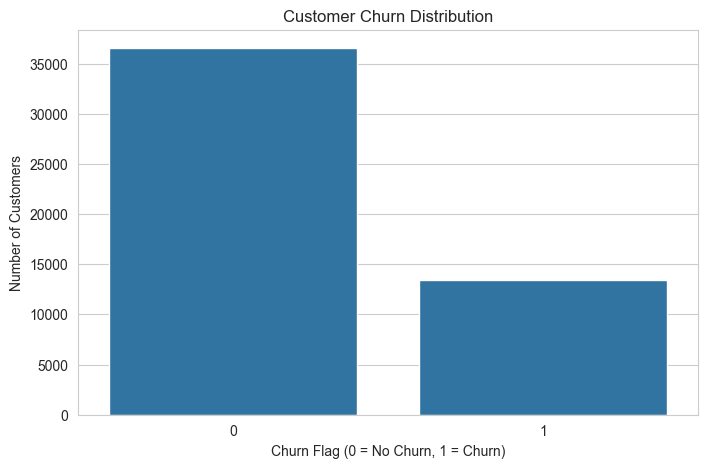

In [5]:
# How many customers are churning?

sns.countplot(
    data=df,
    x="churn_flag"
)

plt.title(
    "Customer Churn Distribution"
)

plt.xlabel(
    "Churn Flag (0 = No Churn, 1 = Churn)"
)

plt.ylabel(
    "Number of Customers"
)


plt.savefig(
    "../reports/figures/churn_distribution.png",
    bbox_inches="tight"
)


plt.show()

In [6]:
churn_percentage = (
    df["churn_flag"]
    .value_counts(normalize=True)
    * 100
)

churn_percentage

churn_flag
0    73.086
1    26.914
Name: proportion, dtype: float64

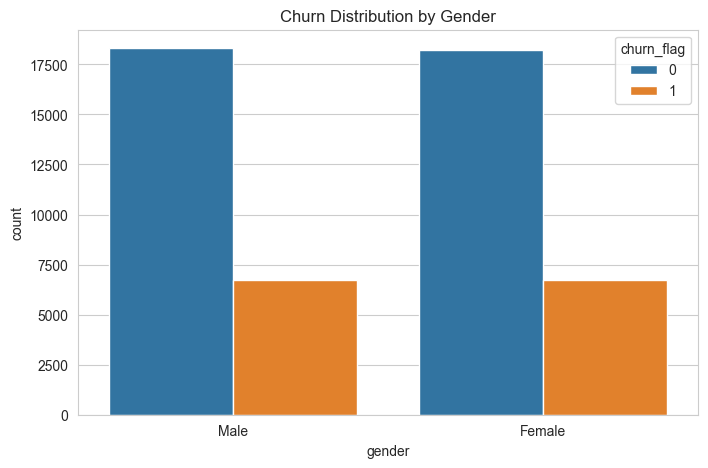

In [7]:
#Churn by gender

sns.countplot(
    data=df,
    x="gender",
    hue="churn_flag"
)

plt.title(
    "Churn Distribution by Gender"
)


plt.savefig(
    "../reports/figures/gender_vs_churn.png",
    bbox_inches="tight"
)


plt.show()

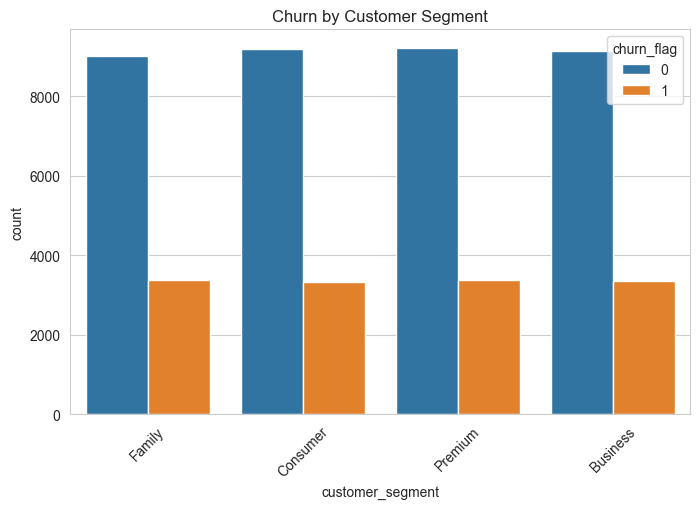

In [8]:
# Churn by Customer Segment

sns.countplot(
    data=df,
    x="customer_segment",
    hue="churn_flag"
)

plt.title(
    "Churn by Customer Segment"
)

plt.xticks(
    rotation=45
)


plt.savefig(
    "../reports/figures/customer_segment_vs_churn.png",
    bbox_inches="tight"
)


plt.show()

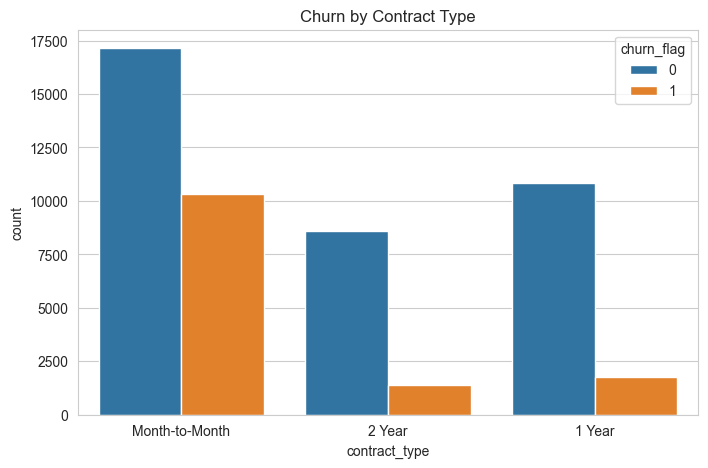

In [9]:
# Churn by Contract Type

sns.countplot(
    data=df,
    x="contract_type",
    hue="churn_flag"
)


plt.title(
    "Churn by Contract Type"
)


plt.savefig(
    "../reports/figures/contract_type_vs_churn.png",
    bbox_inches="tight"
)


plt.show()

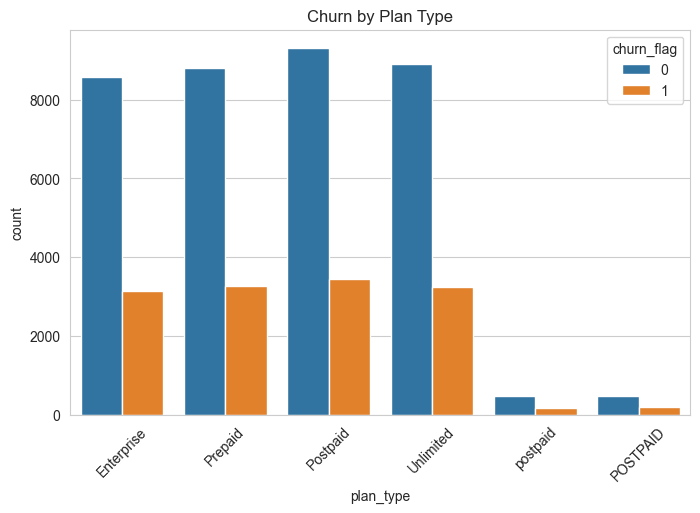

In [10]:
# Churn by Plan Type

sns.countplot(
    data=df,
    x="plan_type",
    hue="churn_flag"
)

plt.title(
    "Churn by Plan Type"
)

plt.xticks(
    rotation=45
)


plt.savefig(
    "../reports/figures/plan_type_vs_churn.png",
    bbox_inches="tight"
)


plt.show()

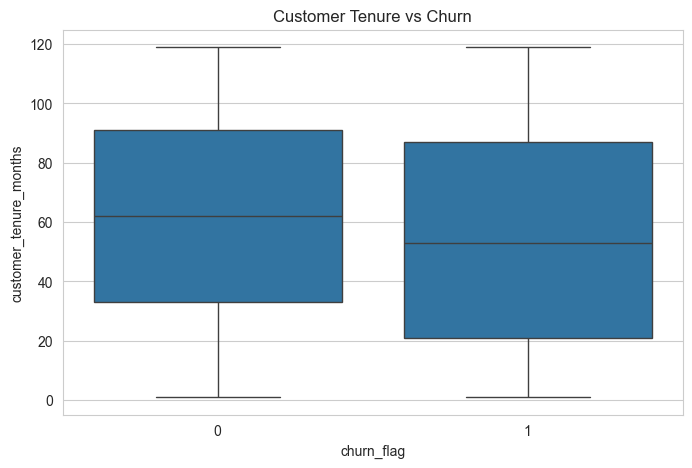

In [11]:
# Are newer customers more likely to leave?
# Tenure Analysis

sns.boxplot(
    data=df,
    x="churn_flag",
    y="customer_tenure_months"
)


plt.title(
    "Customer Tenure vs Churn"
)


plt.savefig(
    "../reports/figures/tenure_vs_churn.png",
    bbox_inches="tight"
)


plt.show()

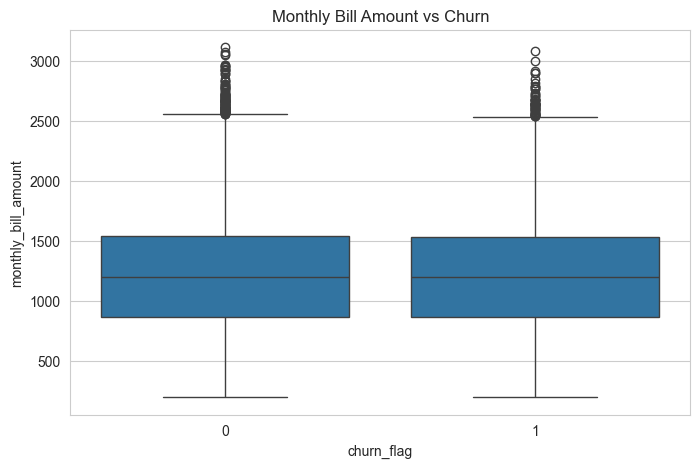

In [12]:
# Are high-paying customers leaving?

sns.boxplot(
    data=df,
    x="churn_flag",
    y="monthly_bill_amount"
)


plt.title(
    "Monthly Bill Amount vs Churn"
)


plt.savefig(
    "../reports/figures/monthly_bill_vs_churn.png",
    bbox_inches="tight"
)


plt.show()

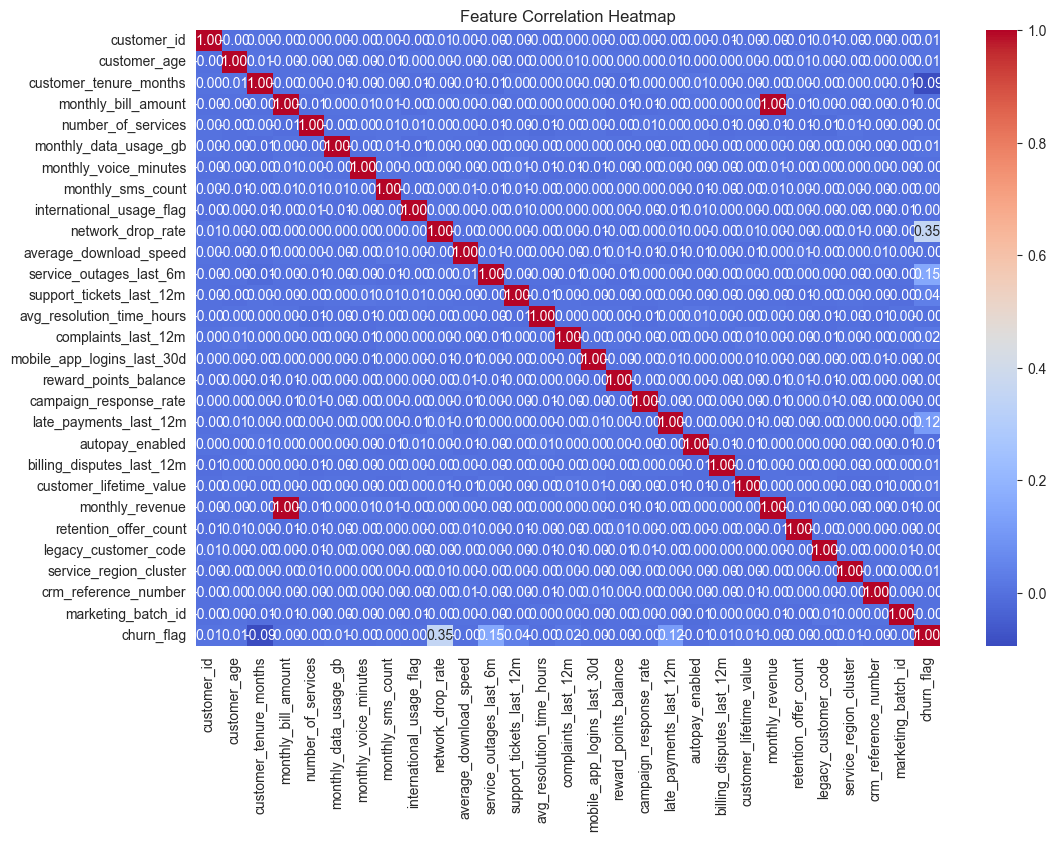

In [13]:
numeric_df = df.select_dtypes(
    include=["int64","float64"]
)


plt.figure(
    figsize=(12,8)
)


sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)


plt.title(
    "Feature Correlation Heatmap"
)


plt.savefig(
    "../reports/figures/correlation_heatmap.png",
    bbox_inches="tight"
)


plt.show()

In [ ]:
## Key Findings

Examples:

1. Customers with shorter tenure show higher churn risk.

2. Contract type has a strong relationship with churn.

3. Customers with billing disputes have higher churn probability.

4. Certain customer segments show higher attrition rates.

5. Revenue and service usage patterns can help identify high-risk customers.

These insights guide feature selection and model development.